# Exploring Training and Validation Sets

In this notebook, we’ll learn how to split data into two important parts: a training set and a validation set. You’ll see how we train models on one part of the data and then test how well they perform on new data they haven’t seen before. This helps us figure out which model is truly the best at making predictions, not just memorizing!

By the end, you’ll understand why good machine learning isn’t just about fitting data well, but about choosing models that can handle new, unseen data confidently.


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import polyfit
import pathlib as pl
import os
import pandas as pd
np.random.seed(1) # set the random seed for reproducibility


import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [14]:
def polynomial(x, coeffs):
    """calculates y values of polynomial at inputs x
    :param x: the input values the polynomial is to be evaluated at
    :param coeffs: the coefficients of the polynomial. The polynomial is of order len(coeffs)-1 """
    poly = np.poly1d(coeffs)
    return poly(x)

In [16]:
path_csv = pl.Path(os.getcwd()) / f'C5_dataset.csv'
with open(path_csv, 'rb') as file:
    data_pd = pd.read_csv(file)

data = {'X':data_pd['x'].to_numpy(), 'Y':data_pd['y'].to_numpy()}

## Section 1: Picking the Best Model

### Task 1.1: Splitting the Data: Why It Matters

Before we build any machine learning model, we need to divide our data into three parts to make sure we’re doing things properly and not accidentally fooling ourselves. Here’s the plan:
	•	Training set (40%): This is where the model learns patterns from the data. Think of it as the “study material” for your model.
	•	Validation set (30%): After learning, we check how well the model is doing on new data. This helps us tweak and improve the model without seeing the final test yet. It’s like practicing with mock exams.
	•	Test set (30%): This is the final exam! It tells us how good the model really is when facing completely unseen data.

To make this happen, we use a function called split_data that automatically chops up the data into these pieces. Our goal here is to split the data into 40% training, 30% validation, and 30% test, a nice balance that gives us enough data to both learn and test properly.


In [25]:
def split_data(data_dict, data_split):
    """divide the data into training, validate and test sets.
    :param data_dict: a dictionary of the data with keys 'X' and 'Y'
    :param data_split: a list of the fraction of the data to be in each set of form
    [training_fraction, validation_fraction, test_fraction]. The fractions should all add up to 1.
    :returns training_dict, validation_dict, test_dict: dictionaries of the same form as the data_dict,
    containing the different sets"""

    assert np.sum(data_split)-1 < 0.01

    # work out how many datapoints will be in the train and validation sets
    n_train = int(len((data_dict['X']))*data_split[0])
    n_validate = int(len((data_dict['X']))*data_split[1])

    # generate a random permutation of indices of the data and split into training, validation and test
    perm = np.random.permutation(range(len(data_dict['X'])))
    indices_train, indices_validate, indices_test = np.split(perm, [n_train, n_train+ n_validate])

    # create training, validation and test dictionaries
    training_dict = {'X': data['X'][indices_train], 'Y': data['Y'][indices_train]}
    validation_dict = {'X': data['X'][indices_validate], 'Y': data['Y'][indices_validate]}
    test_dict = {'X': data['X'][indices_test], 'Y': data['Y'][indices_test]}

    return training_dict, validation_dict, test_dict

Use `split_data()` for splitting the data into 40% training data, 30% validation data and 30% test_data.

In [28]:
# split the data into training, validation and test sets
training_data, validation_data, test_data = split_data(data, [0.4, 0.3, 0.3])


### Task 1.2: Fit the Models

Your goal here is to fit different curved lines (polynomials) to your training data to see which one matches best.

We’ll use the NumPy polyfit() function, which helps us draw lines of different complexity. You’ll start with a straight line (order 1), then try more flexible curves (orders 2 through 6).

For each curve you fit, save its equation’s coefficients in a dictionary. The dictionary should look like this:

{ 1: array_of_coefficients, 2: array_of_coefficients, ..., 6: array_of_coefficients }

This way, you can easily check what each model looks like later.

HINT: Use np.polyfit() to do the fitting. You give it your X and y data, and it gives you the coefficients of the best-fitting line or curve.

In [31]:
orders = list(range(1, 7))
coefficients = {}
for order in orders:
    coeffs = np.polyfit(training_data['X'], training_data['Y'], order)
    coefficients[order] = coeffs

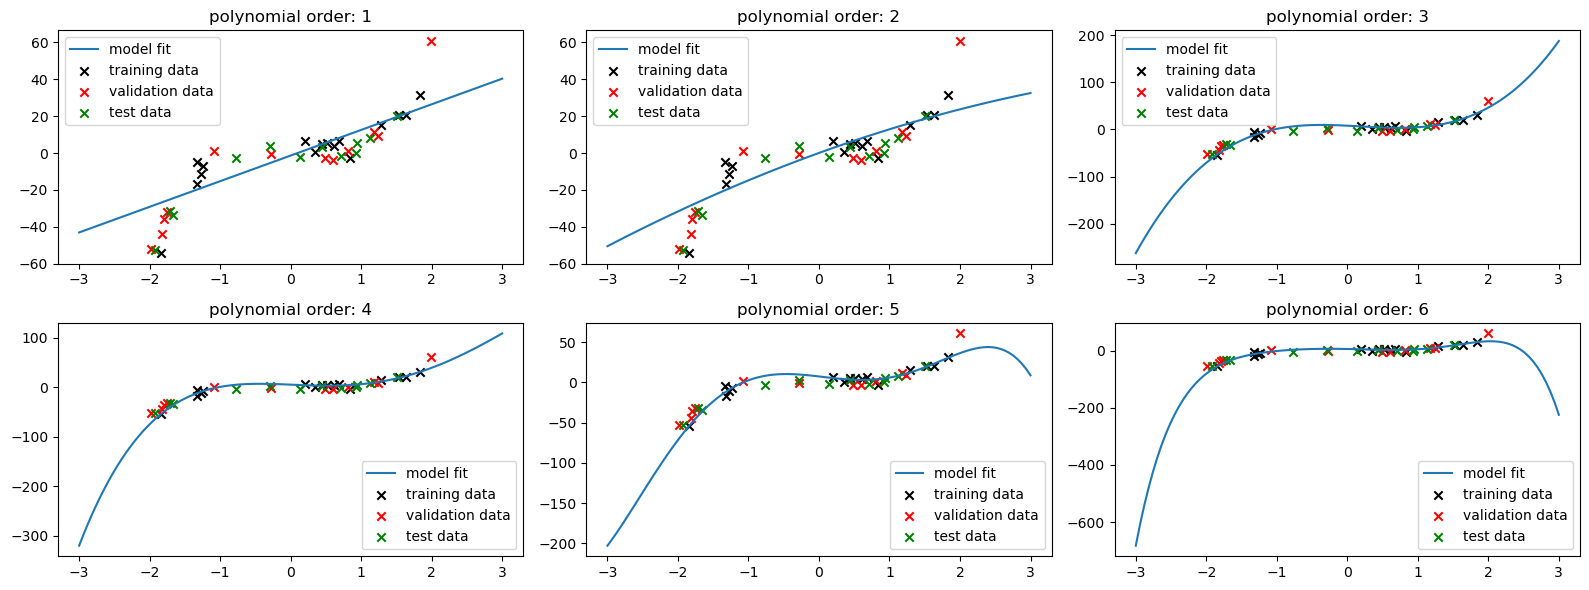

In [33]:
#### Plot each of the fitted models along with the training and validation data

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(16, 6))
ax = axs.flatten()

x_plot = np.linspace(-3, 3, 100)

for i, coeffs in enumerate(coefficients.values()):
    ax[i].plot(x_plot, polynomial(x_plot, coeffs), label='model fit')
    ax[i].scatter(training_data['X'], training_data['Y'], marker='x', color='k', label='training data')
    ax[i].scatter(validation_data['X'], validation_data['Y'], marker='x', color='r', label='validation data')
    ax[i].scatter(test_data['X'], test_data['Y'], marker='x', color='g', label='test data')
    ax[i].set_title(f'polynomial order: {list(coefficients.keys())[i]}')
    ax[i].legend()
plt.tight_layout()
plt.legend()



### Task 1.3: Check How Well Your Model Fits (Using RMSE)

In this task, you’ll measure how good (or bad!) your model’s predictions are for both:
	•	The training set (the data your model learned from)
	•	The validation set (new data your model hasn’t seen yet)

We’ll do this using something called the Root Mean Squared Error (RMSE). Think of RMSE as a score that tells you how far off your model’s guesses are from the actual answers. The smaller the RMSE, the better your model is doing.

What to do:
	1.	Calculate RMSE for both the training and validation sets.
(Hint: use your polynomial() function to make predictions!)
	2.	Plot the RMSEs on a graph.
This will help you visualize which model works best.
	3.	Pick the best model.
The best model is the one with the lowest validation RMSE (because we care most about how well it works on new data!).

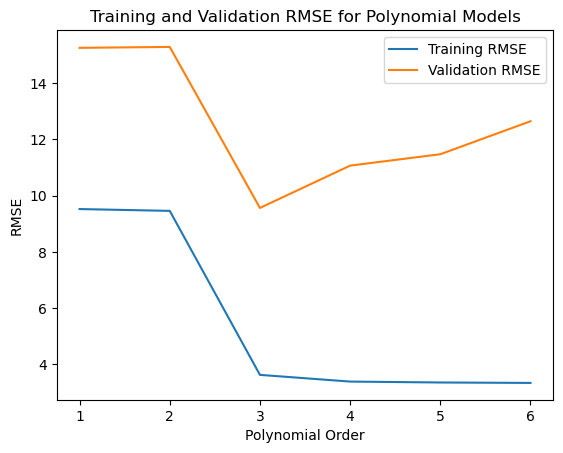

Best model order: 3
best model: 3


In [36]:
training_model_value = []
training_RMSEs = []
validation_model_value = []
validation_RMSEs = []

# Calculate RMSE for training and validation sets
for order in orders:
    # Predict values on training and validation sets
    training_model_value.append(polynomial(training_data['X'], coefficients[order]))
    validation_model_value.append(polynomial(validation_data['X'], coefficients[order]))

    # Calculate RMSE
    training_RMSEs.append(np.sqrt(np.mean((training_data['Y'] - training_model_value[-1])**2)))
    validation_RMSEs.append(np.sqrt(np.mean((validation_data['Y'] - validation_model_value[-1])**2)))

# Plot the RMSE values
plt.plot(orders, training_RMSEs, label='Training RMSE')
plt.plot(orders, validation_RMSEs, label='Validation RMSE')
plt.xlabel('Polynomial Order')
plt.ylabel('RMSE')
plt.title('Training and Validation RMSE for Polynomial Models')
plt.legend()
plt.show()

# Find the best model based on validation RMSE
best_order = np.argmin(validation_RMSEs) + 1
print("Best model order:", best_order)
#######################
### TO DO ###



#######################

best = np.argmin(validation_RMSEs)
print('best model:', orders[best])

##  Part 2: How Well Does Your Model Really Perform?

Now that you’ve picked your model, it’s time for the final test.

### Task 2.1: Test Your Model’s Performance

Here’s what you’ll do:

Use the test set (this is the data your model has never seen before) to check how well your model really performs in the real world.

Calculate the RMSE (Root Mean Squared Error) by comparing your model’s predictions to the actual values in the test set.

This score will tell you how far off your model’s predictions are from the true answers. The smaller the RMSE, the better!

⸻

Why is this important?
	•	The test set gives us an honest check. It shows if the model can handle totally new data—just like it would in the real world.
	•	Even if your model did great on the training and validation sets, the true test is how it performs here.

When you’re done, you’ll know whether your model is ready to be trusted—or if it might still need improvement.

In [39]:
best_model_order = np.argmin(validation_RMSEs)

In [41]:
# Calculate model predictions for the test set

test_model_value = polynomial(test_data['X'], coefficients[best_model_order])

# Calculate RMSE for the test set
test_RMSE = np.sqrt(np.mean((test_data['Y'] - test_model_value)**2))
print('RMSE on the test set:', test_RMSE)


RMSE on the test set: 9.525186388878703


### How Well Did the Model Do on New Data?

We tested the model on completely new data (the test set), and its Root Mean Squared Error (RMSE) was about 9.53.

This number tells us that, on average, the model’s predictions were around 9.5 units away from the actual values. The smaller this number, the better the model is at making accurate predictions!